### Nhập thư viện cần thiết

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

### Định nghĩa đường dẫn và các tham số

In [ ]:
CSV_PATH = "diabetes_prediction_dataset.csv"
FEATURES = ["bmi", "HbA1c_level"]  
TARGET = "diabetes"
C = 1.0   # Regularisation

### Load dữ liệu từ CSV

In [ ]:
import pandas as pd
df = pd.read_csv(CSV_PATH)
for c in FEATURES + [TARGET]:
    if c not in df.columns:
        raise KeyError(f"Thiếu cột trong CSV: {c}")

data = df[FEATURES + [TARGET]].dropna()
X = data[FEATURES].astype(float).to_numpy()
y = data[TARGET].astype(int).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=109)

### Tạo mô hình SVM với dữ liệu đã chuẩn bị 

In [ ]:
from sklearn import svm
clf = svm.LinearSVC(C=C, dual=False, max_iter=5000).fit(X_train, y_train) # LinearSVC thường nhanh hơn cho bài toán tuyến tính số mẫu lớn


### Dự đoán và đánh giá

In [35]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cls_rep = classification_report(
    y_test, y_pred,
    labels=[0, 1],
    target_names=["No diabetes", "Diabetes"],
    digits=4,
    zero_division=0
)

### In kết quả ra màn hình ngay

In [36]:
print("\n".join(report_lines))

SVM Linear Results
CSV: diabetes_prediction_dataset.csv
Features: ['bmi', 'HbA1c_level']
Target: diabetes
Kernel: linear, C=1.0
Train size: 70000, Test size: 30000
Test accuracy: 0.9406
Confusion matrix [[TN, FP], [FN, TP]]: [[27380, 44], [1739, 837]]

Classification report:
              precision    recall  f1-score   support

 No diabetes     0.9403    0.9984    0.9685     27424
    Diabetes     0.9501    0.3249    0.4842      2576

    accuracy                         0.9406     30000
   macro avg     0.9452    0.6617    0.7264     30000
weighted avg     0.9411    0.9406    0.9269     30000



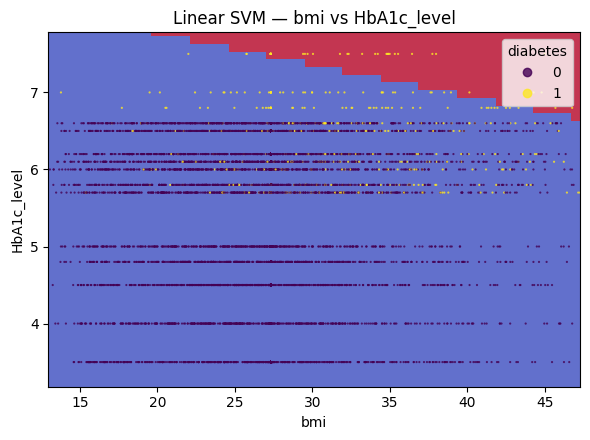

In [37]:

# Bước lưới thích ứng theo diện tích và mục tiêu số điểm (giới hạn tối thiểu để hình hiển thị thoáng)
area = max((x_max - x_min) * (y_max - y_min), 1e-6)
h = max(0.10, (area / TARGET_GRID_POINTS) ** 0.5)
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(6, 4.5))
# pcolormesh thường nhanh hơn contourf với lưới thưa
plt.pcolormesh(xx, yy, Z, shading='auto', cmap=plt.cm.coolwarm, alpha=0.8)

# Vẽ scatter tối ưu render 
scat = plt.scatter(
    X_plot[:, 0], X_plot[:, 1],
    c=y_plot, s=10, marker='.', edgecolors='none', rasterized=True, alpha=0.8
)
plt.legend(*scat.legend_elements(), loc="upper right", title=TARGET)
plt.xlabel(FEATURES[0])
plt.ylabel(FEATURES[1])
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title(f"Linear SVM — {FEATURES[0]} vs {FEATURES[1]}")
plt.tight_layout()
plt.show()